# Stage 7 Homework — Outliers + Risk Assumptions
In this assignment you will implement outlier detection/handling and run a simple sensitivity analysis.

**Chain:** In the lecture, we learned detection (IQR, Z-score), options for handling (remove/winsorize), and sensitivity testing. Now, you will adapt those methods to a provided dataset and document the risks and assumptions behind your choices.

## Setup - Generate the Dataset

This cell creates the required folder structure (`data/raw/` and `data/processed/`) relative to the notebook, and generates the sample CSV dataset: business-day dates from 2022-01-03 to 2022-06-10, a `daily_return` column that sits slightly lower before May, five large shock values injected in May, and a second column `daily_return_2` correlated with the first. The dataset has NO missing values - filling those in was stage 06; this stage is about outliers. 
It saves the file under `data/raw/`; the load cell below reads back that same path from the `csv_path` variable, so the filename is written in exactly one place.

In [66]:
# --- packages this notebook needs (uncomment and run once, then re-comment) ---
# !pip install numpy
# !pip install pandas
# !pip install matplotlib
# !pip install scikit-learn

In [67]:
import os
import numpy as np
import pandas as pd

# Define folder paths relative to this notebook
raw_dir = 'data/raw'
processed_dir = 'data/processed'

# Create folders if they don't exist
os.makedirs(raw_dir, exist_ok=True)
os.makedirs(processed_dir, exist_ok=True)

# Generate business day dates
dates = pd.date_range(start="2022-01-03", end="2022-06-10", freq="B")

# Fixed random seed for reproducibility
np.random.seed(17)

# Column 1: daily_return ~ N(0, 0.01)
returns = np.random.normal(0, 0.01, size=len(dates))
mask_pre_may = dates < "2022-05-01"
returns[mask_pre_may] -= 0.0015  

# Inject "shock" values
shock_values = {
    "2022-05-02": 0.1748425237194541,
    "2022-05-03": -0.16825801732486943,
    "2022-05-06": -0.19667220757153227,
    "2022-05-09": 0.21240223590614747,
    "2022-05-12": -0.178729287231294
}
for d, v in shock_values.items():
    idx = np.where(dates == pd.to_datetime(d))[0][0]
    returns[idx] = v

# Column 2: daily_return_2, correlated with daily_return + small noise
daily_return_2 = returns * 0.6 + np.random.normal(0, 0.005, size=len(dates))

# Create DataFrame with two numeric columns
df = pd.DataFrame({
    "date": dates,
    "daily_return": returns,
    "daily_return_2": daily_return_2
})

# Save to CSV in raw data folder
csv_path = os.path.join(raw_dir, 'outliers_homework.csv')
if not os.path.exists(csv_path):
    df.to_csv(csv_path, index=False)
    print(f'Synthetic dataset with two columns created and saved to {csv_path}')
else:
    print(f'File already exists at {csv_path}. Skipping CSV creation to avoid overwrite.')

File already exists at data/raw\outliers_homework.csv. Skipping CSV creation to avoid overwrite.


In [68]:
# Setup
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score
np.random.seed(17)

## Load Data (provided or synthetic fallback)

In [69]:
data_path = Path(csv_path)   # the SAME variable the Setup cell saved to, so the filename is
                             # defined once, up there - renaming it there is enough
if data_path.exists():
    df = pd.read_csv(data_path)
else:
    # Synthetic fallback: linear trend with noise and a few extremes
    x = np.linspace(0, 10, 200)
    y = 2.2 * x + 1 + np.random.normal(0, 1.2, size=x.size)
    y[10] += 15; y[120] -= 13; y[160] += 18
    df = pd.DataFrame({'x': x, 'y': y})
df.head()

,date,daily_return,daily_return_2
0,2022-01-03,0.001263,0.003834
1,2022-01-04,-0.020046,-0.009506
2,2022-01-05,0.004739,-0.000535
3,2022-01-06,0.009953,0.012539
4,2022-01-07,0.008872,0.009840


## Outlier Functions - Sample Implementations (required)

Both functions below already work. Your job is to **read them, improve them, and then use them** - not to retype them. Worth improving: they silently accept an empty series; they do not state what happens to `NaN`; `detect_outliers_zscore` uses the population standard deviation (`ddof=0`) without saying why; and neither checks that `k` or `threshold` is positive. Document whatever you change, and say in your reflection why it mattered.

In [70]:
def check_data(series):
    """Check for NaN, Inf, and empty series."""
    if series.empty:
        raise ValueError("Series is empty.")
    if series.isnull().any():
        raise ValueError("Series contains NaN values.")
    if np.isinf(series).any():
        raise ValueError("Series contains Inf values.")
    

def detect_outliers_iqr(series: pd.Series, k: float = 1.5) -> pd.Series:
    """Return boolean mask for IQR-based outliers.
    Assumptions: distribution reasonably summarized by quartiles; k controls strictness.
    """
    if k <= 0:
        raise ValueError("k must be positive.")
    check_data(series)
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - k * iqr
    upper = q3 + k * iqr
    return (series < lower) | (series > upper)

def detect_outliers_zscore(series: pd.Series, threshold: float = 3.0) -> pd.Series:
    """Return boolean mask for Z-score outliers where |z| > threshold.
    Assumptions: roughly normal distribution; sensitive to heavy tails.
    """
    if threshold <= 0:
        raise ValueError("threshold must be positive.")
    check_data(series)
    mu = series.mean()
    sigma = series.std(ddof=0)
    z = (series - mu) / (sigma if sigma != 0 else 1.0)
    return z.abs() > threshold

*(Stretch)* A working `winsorize_series` is provided below. Improve it if you can - it does not check that `lower` is below `upper` - then use it in the comparison further down.

In [71]:
def winsorize_series(series: pd.Series, lower: float = 0.05, upper: float = 0.95) -> pd.Series:
    check_data(series)
    if not (0 <= lower < upper <= 1):
        raise ValueError("Lower and upper quantiles must be in [0, 1] and lower < upper.")
    lo = series.quantile(lower)
    hi = series.quantile(upper)
    return series.clip(lower=lo, upper=hi)

## Apply Detection and Create Flags (choose a numeric column)

In [72]:
target_col = 'y' if 'y' in df.columns else df.select_dtypes(include=['number']).columns[0]
print(df.columns)
print(target_col)
df['outlier_iqr'] = detect_outliers_iqr(df[target_col])
df['outlier_z'] = detect_outliers_zscore(df[target_col], threshold=3.0)
df[['outlier_iqr', 'outlier_z']].mean()  # fraction flagged

Index(['date', 'daily_return', 'daily_return_2'], dtype='object')
daily_return


outlier_iqr    0.078261
outlier_z      0.043478
dtype: float64

### Visual Checks (boxplot / histogram)

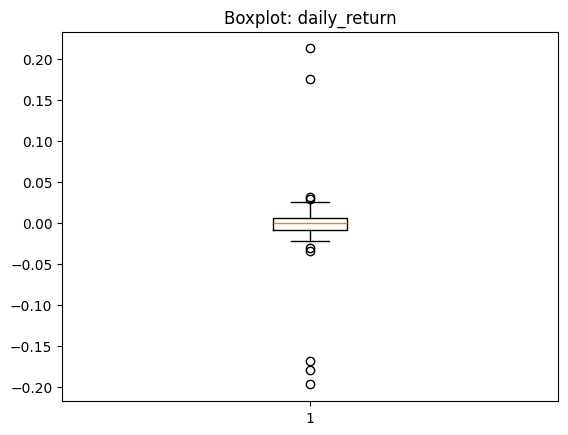

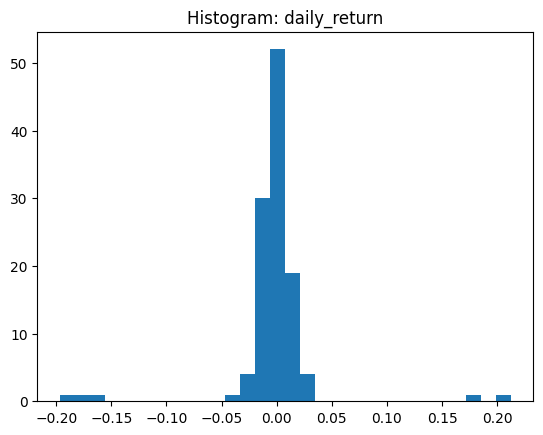

In [73]:
plt.figure()
plt.boxplot(df[target_col])
plt.title(f'Boxplot: {target_col}')
plt.show()

plt.figure()
plt.hist(df[target_col], bins=30)
plt.title(f'Histogram: {target_col}')
plt.show()

## Sensitivity Analysis
Pick one: summary stats or simple linear regression comparing **all vs. filtered** (and optional winsorized).

In [74]:
# Option A: Summary stats
print(target_col)
summ_all = df[target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_filtered = df.loc[~df['outlier_z'], target_col].describe()[['mean', '50%', 'std']].rename({'50%': 'median'})
summ_w = None
if 'winsorize_series' in globals():
    w = winsorize_series(df[target_col])
    summ_w = w.describe()[['mean', '50%', 'std']].rename({'50%': 'median'})

comp = pd.concat(
    {
        'all': summ_all,
        'outlier_z': summ_filtered,
        **({'winsorized': summ_w} if summ_w is not None else {})
    }, axis=1
)

comp

daily_return


,all,outlier_z,winsorized
mean,-0.001434,-0.000078,-0.000251
median,-0.000187,-0.000100,-0.000187
std,0.040579,0.011059,0.010623


regressing daily_return_2 on daily_return
daily_return_2


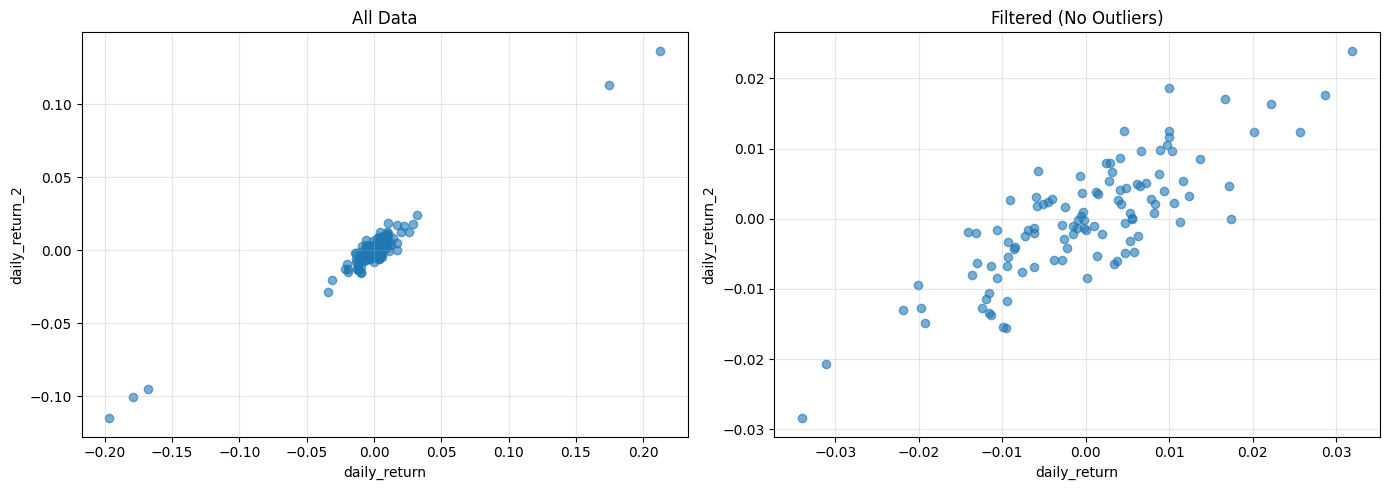

,slope,intercept,r2,mae
all,0.605869,0.000201,0.961859,0.003951
filtered_z,0.630315,-0.000088,0.679331,0.003848


In [75]:
# Option B: Simple regression - did removing the outliers give us a BETTER model?
# The dataset has two correlated numeric columns, so regress one on the other.
resp_col = [c for c in df.columns
            if c != target_col and c != 'date' and not str(c).startswith('outlier_')][0]
print('regressing %s on %s' % (resp_col, target_col))
print(resp_col)
keep = ~df['outlier_z']            # the flag from the cell above
X_all = df[[target_col]].to_numpy(); y_all = df[resp_col].to_numpy()
X_filtered = df.loc[keep, [target_col]].to_numpy(); y_filtered = df.loc[keep, resp_col].to_numpy()


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(X_all, y_all, alpha=0.6)
axes[0].set_xlabel('daily_return')
axes[0].set_ylabel('daily_return_2')
axes[0].set_title('All Data')
axes[0].grid(True, alpha=0.3)

normal = df[~df['outlier_z']]
axes[1].scatter(X_filtered, y_filtered, alpha=0.6)
axes[1].set_xlabel('daily_return')
axes[1].set_ylabel('daily_return_2')
axes[1].set_title('Filtered (No Outliers)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


model_all = LinearRegression().fit(X_all, y_all)
model_flt = LinearRegression().fit(X_filtered, y_filtered)

mae_all = mean_absolute_error(y_all, model_all.predict(X_all))
mae_flt = mean_absolute_error(y_filtered, model_flt.predict(X_filtered))

results = pd.DataFrame({
    'slope': [model_all.coef_[0], model_flt.coef_[0]],
    'intercept': [model_all.intercept_, model_flt.intercept_],
    'r2': [model_all.score(X_all, y_all), model_flt.score(X_filtered, y_filtered)],
    'mae': [mae_all, mae_flt]
}, index=['all', 'filtered_z'])

# Read the r2 column before you conclude that removing outliers helped.
results

## Reflection (≤ 1 page)
- Methods and thresholds used (and why)
- Assumptions behind choices
- Observed impact on results
- Risks if assumptions are wrong (e.g., discarding true events)

### Method
I choose `zscore` for outlier, because the box plot shows that some points, which might be normal, are droped. For `winsorize`, it will change bad points to the boundary level instead of dropping them, which is not a good idea for me, because it also introduces unusual grouped points. And for the `threshold`, 0.3 is good because the data is produced by normal distribution.
### Assumptions
The data is roughly normal.
### Observed Impact
For summary stats, it makes the data more like normal distribution. For simple regression, it's fun that removing makes the R^2 worse. It is because when producing data, the unnormal event happens to `daily_return` at first, the we make `daily_return_2 = 0.6 * daily_return`, which is actually not practical. And, `iqr` performs here worse than `zscore` because it moves more points.
### Risks
If the data is roughly normal, for example, it has heavy tails, the outlier will mask many good points as bad ones. And it will lead to mistake.